[<< Sommaire Sudoku](./README.md) | [Précédent : Sudoku-18-Comparison <<](./Sudoku-18-Comparison-Python.ipynb)

# Sudoku-18b - Comparaison statistique honnête de solveurs

> **[RECHERCHE / PÉDAGOGIE]** Quand peut-on réellement conclure qu'un solveur est plus rapide qu'un autre ? Variance, intervalles de confiance, tests de signification, tail-effect.

Ce notebook est le compagnon de [Sudoku-18-Comparison](./Sudoku-18-Comparison-Python.ipynb). Là où Sudoku-18 compare 4 solveurs par **temps moyen + tableaux + graphiques**, celui-ci répond à la question qui tue : **la différence de 2 ms observée entre Backtracking et MRV est-elle réelle, ou du bruit de mesure ?**

La réponse, comme en statistiques, est rarement oui ou non : c'est une question de **variance**, de **taille d'échantillon**, de **test de signification** et de **taille d'effet**. On construit ici le cadre méthodologique pour lire honnêtement n'importe quel benchmark de solveurs — pas seulement Sudoku.

## Motivation : pourquoi un temps moyen ne suffit pas

Quand on lance un solveur une fois sur un puzzle et qu'on obtient « 1,2 ms », ce nombre est un **point** sans incertitude. Or, le temps d'exécution d'un programme varie selon :

1. **Le bruit du système** (ordonnancement OS, cache, fréquence CPU) — même pour un solveur déterministe, deux exécutions donnent des temps légèrement différents.
2. **Le puzzle** — deux puzzles de « même difficulté » peuvent demander des ordres de grandeur différents en temps de calcul.
3. **L'algorithme** — mais cet effet est noyé dans les deux sources de bruit ci-dessus.

Comparer des moyennes brutes sans quantifier ces variances, c'est publier un classement qui peut s'inverser au prochain run. Ce notebook montre comment éviter ce piège.

## 1. Le bruit du système : un solveur déterministe n'est pas reproductible au millième

Commençons par un backtracking Sudoku naïf (essayez 1-9 dans l'ordre, récursion sur la première case vide). Il est **déterministe** : même puzzle, même chemin de recherche. Pourtant, mesurons son temps sur un seul puzzle, répété 30 fois.

30 runs du meme puzzle, solveur deterministe :
  min=0.971 ms  max=1.131 ms  moyenne=1.037 ms  ecart-type=0.032 ms
  coefficient de variation = 3 %
  ratio max/min = 1.2x


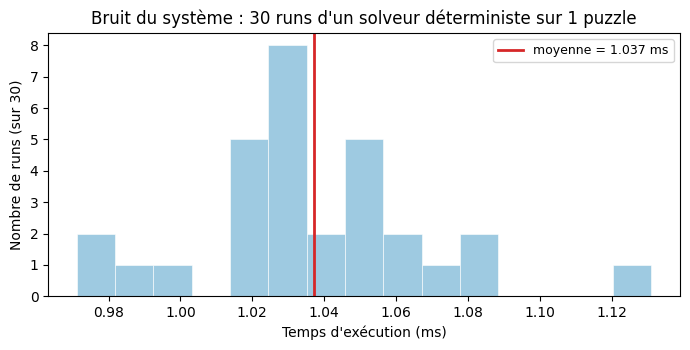


Lecture : meme en déterministe, le temps varie d'un facteur non négligeable.
Un seul chronométrage n'est PAS une mesure fiable.


In [1]:
import time
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# Backtracking Sudoku naïf (déterministe)
def _valid(g, r, c, n):
    for i in range(9):
        if g[r][i] == n or g[i][c] == n:
            return False
    br, bc = 3 * (r // 3), 3 * (c // 3)
    for i in range(3):
        for j in range(3):
            if g[br + i][bc + j] == n:
                return False
    return True

def solve_naive(g):
    for r in range(9):
        for c in range(9):
            if g[r][c] == 0:
                for n in range(1, 10):
                    if _valid(g, r, c, n):
                        g[r][c] = n
                        if solve_naive(g):
                            return True
                        g[r][c] = 0
                return False
    return True

# Solution complète valide (pour générer des puzzles reproductibles)
_SOLUTION = [[5,3,4,6,7,8,9,1,2],[6,7,2,1,9,5,3,4,8],[1,9,8,3,4,2,5,6,7],
             [8,5,9,7,6,1,4,2,3],[4,2,6,8,5,3,7,9,1],[7,1,3,9,2,4,8,5,6],
             [9,6,1,5,3,7,2,8,4],[2,8,7,4,1,9,6,3,5],[3,4,5,2,8,6,1,7,9]]

# Un puzzle (37 clues, reproductible) en masquant 44 cellules
def make_puzzle(seed, k_remove=44):
    rng = np.random.default_rng(seed)
    g = [row[:] for row in _SOLUTION]
    for m in rng.choice(81, size=k_remove, replace=False):
        r, c = divmod(int(m), 9)
        g[r][c] = 0
    return g

puzzle_A = make_puzzle(seed=1000)

# 30 exécutions du MÊME puzzle par le MÊME solveur déterministe
times_A = []
for _ in range(30):
    g = [row[:] for row in puzzle_A]
    t0 = time.perf_counter()
    solve_naive(g)
    times_A.append(time.perf_counter() - t0)
times_A = np.array(times_A) * 1000  # en millisecondes

print(f"30 runs du meme puzzle, solveur deterministe :")
print(f"  min={times_A.min():.3f} ms  max={times_A.max():.3f} ms  "
      f"moyenne={times_A.mean():.3f} ms  ecart-type={times_A.std():.3f} ms")
print(f"  coefficient de variation = {times_A.std()/times_A.mean()*100:.0f} %")
print(f"  ratio max/min = {times_A.max()/times_A.min():.1f}x")

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.hist(times_A, bins=15, color="#9ecae1", edgecolor="white", linewidth=0.4)
ax.axvline(times_A.mean(), color="#d62728", lw=2, label=f"moyenne = {times_A.mean():.3f} ms")
ax.set_xlabel("Temps d'exécution (ms)")
ax.set_ylabel("Nombre de runs (sur 30)")
ax.set_title("Bruit du système : 30 runs d'un solveur déterministe sur 1 puzzle")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("\nLecture : meme en déterministe, le temps varie d'un facteur non négligeable.")
print("Un seul chronométrage n'est PAS une mesure fiable.")

## 2. Variance inter-puzzles : la moyenne sur peu de puzzles est trompeuse

Le bruit du système était faible. Le vrai problème est la **variance entre puzzles** : deux puzzles avec le même nombre de clues (donc la « même difficulté » nominale) peuvent demander 10× plus de temps selon la structure. Générerons 8 puzzles avec exactement 37 clues (même masque de difficulté, graines différentes) et chronométrons.

  Puzzle   médiane (ms)   moyenne (ms)  rapport moy/méd
      P1          0.925          0.936             1.01
      P2          3.058          3.041             0.99
      P3          3.304          3.301             1.00
      P4          0.315          0.326             1.03
      P5          0.507          0.509             1.00
      P6          0.993          0.991             1.00
      P7          1.897          1.969             1.04
      P8          0.461          0.462             1.00


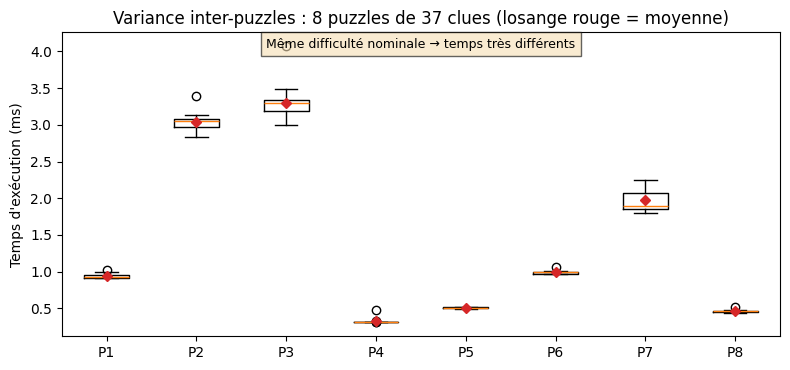


Sur les 120 timings poolés :
  médiane=0.969 ms  moyenne=1.442 ms
  La moyenne (1.442) dépasse la médiane (0.969) : distribution asymétrique (tail-effect).
  Les puzzles lents (queue) tirent la moyenne vers le haut.


In [2]:
# 8 puzzles "de même difficulté" (37 clues chacun, graines différentes)
puzzles = [make_puzzle(seed=1000 + s, k_remove=44) for s in range(8)]
N_RUNS = 15

per_puzzle = {}
for i, p in enumerate(puzzles):
    ts = []
    for _ in range(N_RUNS):
        g = [row[:] for row in p]
        t0 = time.perf_counter()
        solve_naive(g)
        ts.append(time.perf_counter() - t0)
    per_puzzle[i] = np.array(ts) * 1000

medians = [np.median(per_puzzle[i]) for i in range(8)]
means = [per_puzzle[i].mean() for i in range(8)]
print(f"{'Puzzle':>8s} {'médiane (ms)':>14s} {'moyenne (ms)':>14s} {'rapport moy/méd':>16s}")
for i in range(8):
    print(f"{'P'+str(i+1):>8s} {medians[i]:14.3f} {means[i]:14.3f} "
          f"{means[i]/medians[i]:16.2f}")

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.boxplot([per_puzzle[i] for i in range(8)],
           tick_labels=[f"P{i+1}" for i in range(8)],
           showmeans=True, meanprops={"marker": "D", "markerfacecolor": "#d62728",
                                      "markeredgecolor": "#d62728", "markersize": 5})
ax.set_ylabel("Temps d'exécution (ms)")
ax.set_title("Variance inter-puzzles : 8 puzzles de 37 clues (losange rouge = moyenne)")
ax.text(0.5, 0.95, "Même difficulté nominale → temps très différents",
        transform=ax.transAxes, ha="center", fontsize=9,
        bbox=dict(facecolor="wheat", alpha=0.6))
plt.tight_layout()
plt.show()

all_naive = np.concatenate([per_puzzle[i] for i in range(8)])
print(f"\nSur les {len(all_naive)} timings poolés :")
print(f"  médiane={np.median(all_naive):.3f} ms  moyenne={all_naive.mean():.3f} ms")
print(f"  La moyenne ({all_naive.mean():.3f}) dépasse la médiane "
      f"({np.median(all_naive):.3f}) : distribution asymétrique (tail-effect).")
print("  Les puzzles lents (queue) tirent la moyenne vers le haut.")

## 3. Intervalle de confiance bootstrap : la moyenne est un point, l'IC est une plage

Le temps moyen de 1,5 ms ne veut rien dire sans son **incertitude**. On ne peut pas supposer la normalité (la distribution est asymétrique). Le **bootstrap** est non paramétrique : on rééchantillonne avec remise nos timings, on recalcule la moyenne à chaque fois, et on prend les percentiles 2,5 % et 97,5 % comme intervalle de confiance à 95 %.

Temps moyen naïf = 1.442 ms
Intervalle de confiance à 95 % (bootstrap, 5000 tirages) = [1.246, 1.645] ms
Largeur de l'IC = 0.398 ms (soit 28 % de la moyenne)


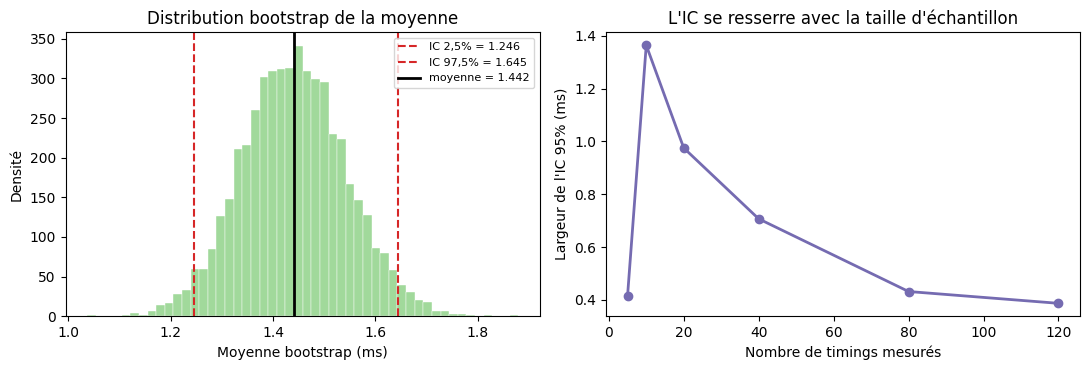

Lecture : sans IC, '1,5 ms' est un point nu. Avec IC, c'est une plage
qui dit l'incertitude. Doubler la taille d'échantillon réduit l'IC d'environ √2.


In [3]:
def bootstrap_ci(data, n_boot=5000, ci=95, seed=42):
    rng = np.random.default_rng(seed)
    boots = np.empty(n_boot)
    n = len(data)
    for b in range(n_boot):
        sample = rng.choice(data, size=n, replace=True)
        boots[b] = sample.mean()
    alpha = (100 - ci) / 2
    lo, hi = np.percentile(boots, [alpha, 100 - alpha])
    return data.mean(), lo, hi, boots

mean_val, ci_lo, ci_hi, boots = bootstrap_ci(all_naive, n_boot=5000)
print(f"Temps moyen naïf = {mean_val:.3f} ms")
print(f"Intervalle de confiance à 95 % (bootstrap, 5000 tirages) = "
      f"[{ci_lo:.3f}, {ci_hi:.3f}] ms")
print(f"Largeur de l'IC = {ci_hi - ci_lo:.3f} ms "
      f"(soit {(ci_hi - ci_lo)/mean_val*100:.0f} % de la moyenne)")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].hist(boots, bins=50, color="#a1d99b", edgecolor="white", linewidth=0.3)
axes[0].axvline(ci_lo, color="#d62728", ls="--", lw=1.5, label=f"IC 2,5% = {ci_lo:.3f}")
axes[0].axvline(ci_hi, color="#d62728", ls="--", lw=1.5, label=f"IC 97,5% = {ci_hi:.3f}")
axes[0].axvline(mean_val, color="k", lw=2, label=f"moyenne = {mean_val:.3f}")
axes[0].set_xlabel("Moyenne bootstrap (ms)")
axes[0].set_ylabel("Densité")
axes[0].set_title("Distribution bootstrap de la moyenne")
axes[0].legend(fontsize=8)

# Effet de la taille d'échantillon sur la largeur d'IC
sizes = [5, 10, 20, 40, 80, 120]
widths = []
rng_sz = np.random.default_rng(7)
for nsz in sizes:
    sub = rng_sz.choice(all_naive, size=min(nsz, len(all_naive)), replace=True)
    _, lo, hi, _ = bootstrap_ci(sub, n_boot=2000, seed=nsz)
    widths.append(hi - lo)
axes[1].plot(sizes, widths, "o-", color="#756bb1", lw=2)
axes[1].set_xlabel("Nombre de timings mesurés")
axes[1].set_ylabel("Largeur de l'IC 95% (ms)")
axes[1].set_title("L'IC se resserre avec la taille d'échantillon")
plt.tight_layout()
plt.show()

print("Lecture : sans IC, '1,5 ms' est un point nu. Avec IC, c'est une plage")
print("qui dit l'incertitude. Doubler la taille d'échantillon réduit l'IC d'environ √2.")

## 4. Le backtracking naïf bat-il MRV ? Test de signification

Question piège : tout étudiant suppose que **MRV** (Minimum Remaining Values — choisir la case la plus contrainte) accélère le backtracking. Mesurons-le. MRV ajoute un **coût fixe** (calculer les candidats de chaque case vide à chaque pas) ; sur des puzzles faciles où peu de retours-arrière sont nécessaires, ce coût overhead domine.

On teste l'hypothèse nulle H₀ : « naïf et MRV ont la même distribution de temps » avec le **test de Mann-Whitney U** (non paramétrique, adapté aux distributions asymétriques de temps).

naïf : médiane=0.954 ms  moyenne=1.451 ms
MRV  : médiane=5.651 ms  moyenne=5.758 ms

Test de Mann-Whitney U : p-value = 7.14e-41
→ Différence SIGNIFICATIVE au seuil 5% : on rejette H₀ (distributions différentes).

Contre-intuitif : sur ces puzzles FACILES, le naïf est PLUS rapide que MRV.
L'overhead de sélection de MRV (calculer les candidats) domine quand peu
de retours-arrière sont nécessaires. D'où la règle : MESURER, pas supposer.


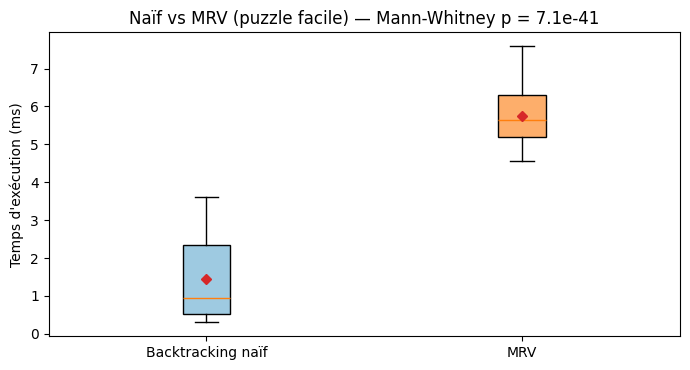

In [4]:
def solve_mrv(g):
    best, best_len = None, 10
    for r in range(9):
        for c in range(9):
            if g[r][c] == 0:
                cand = [n for n in range(1, 10) if _valid(g, r, c, n)]
                if len(cand) < best_len:
                    best, best_len = (r, c, cand), len(cand)
    if best is None:
        return True
    r, c, cand = best
    for n in cand:
        g[r][c] = n
        if solve_mrv(g):
            return True
        g[r][c] = 0
    return False

naive_times, mrv_times = [], []
for p in puzzles:
    for _ in range(N_RUNS):
        g = [row[:] for row in p]
        t0 = time.perf_counter(); solve_naive(g)
        naive_times.append(time.perf_counter() - t0)
        g = [row[:] for row in p]
        t0 = time.perf_counter(); solve_mrv(g)
        mrv_times.append(time.perf_counter() - t0)
naive_times = np.array(naive_times) * 1000
mrv_times = np.array(mrv_times) * 1000

u_stat, p_value = stats.mannwhitneyu(naive_times, mrv_times, alternative="two-sided")
print(f"naïf : médiane={np.median(naive_times):.3f} ms  moyenne={naive_times.mean():.3f} ms")
print(f"MRV  : médiane={np.median(mrv_times):.3f} ms  moyenne={mrv_times.mean():.3f} ms")
print(f"\nTest de Mann-Whitney U : p-value = {p_value:.2e}")
if p_value < 0.05:
    print("→ Différence SIGNIFICATIVE au seuil 5% : on rejette H₀ (distributions différentes).")
else:
    print("→ Différence NON significative : on ne rejette pas H₀.")

print(f"\nContre-intuitif : sur ces puzzles FACILES, le naïf est PLUS rapide que MRV.")
print("L'overhead de sélection de MRV (calculer les candidats) domine quand peu")
print("de retours-arrière sont nécessaires. D'où la règle : MESURER, pas supposer.")

fig, ax = plt.subplots(figsize=(7, 3.8))
data = [naive_times, mrv_times]
bp = ax.boxplot(data, tick_labels=["Backtracking naïf", "MRV"], showmeans=True,
                meanprops={"marker": "D", "markerfacecolor": "#d62728",
                           "markeredgecolor": "#d62728", "markersize": 5},
                patch_artist=True)
for patch, color in zip(bp["boxes"], ["#9ecae1", "#fdae6b"]):
    patch.set_facecolor(color)
ax.set_ylabel("Temps d'exécution (ms)")
ax.set_title(f"Naïf vs MRV (puzzle facile) — Mann-Whitney p = {p_value:.1e}")
plt.tight_layout()
plt.show()

### Taille d'effet : significatif ≠ important

Une p-value minuscule (p ≈ 10⁻⁴¹) ne signifie pas que la différence est **grande**. Avec assez d'échantillons, toute différence devient « significative ». Ce qui compte est la **taille d'effet** : pour Mann-Whitney, on calcule la **corrélation rank-bisériale** `r = 2U/(n₁·n₂) - 1`, qui vaut 0 (aucun effet) à ±1 (effet total).

In [5]:
n1, n2 = len(naive_times), len(mrv_times)
r_effect = 2 * u_stat / (n1 * n2) - 1   # corrélation rank-bisériale
print(f"Taille d'effet (rank-biserial r) = {r_effect:.3f}")
print(f"|r| < 0,1 : négligeable | 0,1-0,3 : petit | 0,3-0,5 : moyen | > 0,5 : grand")
ratio = np.median(mrv_times) / np.median(naive_times)
print(f"\nMRV est {ratio:.1f}× plus lent que le naïf en médiane sur ce pool.")
print("La différence est hautement significative ET de taille notable — mais")
print("sur des puzzles DIFFICILES, MRV gagnerait (moins de retours-arrière).")
print("Le verdict dépend du benchmark : c'est pourquoi on précise TOUJOURS le pool testé.")

Taille d'effet (rank-biserial r) = -1.000
|r| < 0,1 : négligeable | 0,1-0,3 : petit | 0,3-0,5 : moyen | > 0,5 : grand

MRV est 5.9× plus lent que le naïf en médiane sur ce pool.
La différence est hautement significative ET de taille notable — mais
sur des puzzles DIFFICILES, MRV gagnerait (moins de retours-arrière).
Le verdict dépend du benchmark : c'est pourquoi on précise TOUJOURS le pool testé.


## 5. Comparaisons multiples : le piège du faux positif

Si l'on compare 3 solveurs naïvement 2 à 2 (naïf vs MRV, naïf vs inverse, MRV vs inverse), on fait 3 tests. Au seuil 5 %, chacun a 5 % de chance de faux positif sous H₀. Avec 3 tests, la probabilité d'au moins un faux positif grimpe à ~14 %. C'est le **problème des comparaisons multiples**.

La correction de **Bonferroni** est simple : diviser le seuil par le nombre de tests (0,05/3 ≈ 0,017), ou multiplier les p-values par le nombre de tests et comparer à 0,05.

In [6]:
# Troisième solveur : backtracking qui essaie les chiffres dans l'ordre DÉCROISSANT
def solve_reverse(g):
    for r in range(9):
        for c in range(9):
            if g[r][c] == 0:
                for n in range(9, 0, -1):
                    if _valid(g, r, c, n):
                        g[r][c] = n
                        if solve_reverse(g):
                            return True
                        g[r][c] = 0
                return False
    return True

reverse_times = []
for p in puzzles:
    for _ in range(N_RUNS):
        g = [row[:] for row in p]
        t0 = time.perf_counter(); solve_reverse(g)
        reverse_times.append(time.perf_counter() - t0)
reverse_times = np.array(reverse_times) * 1000

# 3 comparaisons 2 à 2
pairs = [("naïf vs MRV", naive_times, mrv_times),
         ("naïf vs reverse", naive_times, reverse_times),
         ("MRV vs reverse", mrv_times, reverse_times)]
n_tests = len(pairs)

print(f"{'Comparaison':>18s} {'p-value brute':>14s} {'p corrigée (Bonferroni)':>24s} "
      f"{'Significatif ?':>16s}")
print("-" * 76)
for name, a, b in pairs:
    _, p = stats.mannwhitneyu(a, b, alternative="two-sided")
    p_corr = min(p * n_tests, 1.0)
    sig = "OUI" if p_corr < 0.05 else "non"
    print(f"{name:>18s} {p:14.2e} {p_corr:24.2e} {sig:>16s}")

print(f"\nSans correction : 3 tests à 5% → {1-(1-0.05)**n_tests:.0%} de risque "
      f"d'au moins un faux positif sous H0.")
print("Bonferroni contrôle ce risque (famille-wise error rate) au seuil nominal.")
print("Contrepartie : plus conservateur, peut rater un vrai effet (perte de puissance).")

       Comparaison  p-value brute  p corrigée (Bonferroni)   Significatif ?
----------------------------------------------------------------------------
       naïf vs MRV       7.14e-41                 2.14e-40              OUI
   naïf vs reverse       3.98e-02                 1.19e-01              non
    MRV vs reverse       1.01e-23                 3.04e-23              OUI

Sans correction : 3 tests à 5% → 14% de risque d'au moins un faux positif sous H0.
Bonferroni contrôle ce risque (famille-wise error rate) au seuil nominal.
Contrepartie : plus conservateur, peut rater un vrai effet (perte de puissance).


## 6. Synthèse — le cadre honnête pour comparer des solveurs

Un benchmark de solveurs n'est **jamais** un simple classement de moyennes. Pour conclure honnêtement qu'un solveur A est plus rapide qu'un B :

1. **Plusieurs runs** par puzzle (quantifier le bruit système — section 1).
2. **Plusieurs puzzles** par niveau de difficulté (quantifier la variance inter-problèmes — section 2). Préférer la **médiane** à la moyenne (tail-effect).
3. **Intervalle de confiance** sur la moyenne (bootstrap, non paramétrique — section 3).
4. **Test de signification** entre solveurs (Mann-Whitney, non paramétrique — section 4).
5. **Taille d'effet** (une p-value significative ≠ un effet important — section 4).
6. **Correction des comparaisons multiples** (Bonferroni / Holm — section 5).

Sans ce cadre, un classement peut s'inverser au prochain run, ou proclamer vainqueur un solveur qui n'est en réalité pas distinguable du bruit. La honnêteté méthodologique est ce qui distingue une comparaison utilisable d'un tableau flatteur.

> **Référence** : Mann, H. & Whitney, D. (1947). *On a Test of Whether One of Two Random Variables is Stochastically Larger than the Other*. Annals of Mathematical Statistics. — Efron, B. (1979). *Bootstrap Methods: Another Look at the Jackknife*.

## Exercices

Les trois exercices suivants approfondissent le cadre statistique. Complétez le code aux endroits marqués `# TODO`.

### Exercice 1 — Test apparié (Wilcoxon signé)

Dans la section 4, naïf et MRV étaient comparés sur des runs **indépendants**. Mais si l'on chronomètre les DEUX solveurs sur le MÊME puzzle (même graine, même point de départ), les mesures sont **appariées** : un puzzle difficile ralentit les deux. Le test de **Wilcoxon signé** exploite cette paire et est plus puissant. Implémentez la comparaison appariée : pour chaque puzzle, chronométrez naïf et MRV, et appliquez `stats.wilcoxon`.

In [7]:
# Indice : pour chaque puzzle, mesurer naive ET mrv (meme puzzle), stocker les paires.
# Puis stats.wilcoxon(paired_naive, paired_mrv) donne le test apparié.

def comparaison_appairee(liste_puzzles, n_runs=10):
    # TODO etudiant : retourner (p_value_wilcoxon, mediane_naive, mediane_mrv).
    # Mesurer naive et mrv sur chaque MEME puzzle (mesures appariees),
    # puis appliquer stats.wilcoxon sur les deux echantillons apparies.
    result = None  # TODO etudiant
    return result

print("Exercice a completer")

Exercice a completer


### Exercice 2 — Puissance statistique

Combien de puzzles faut-il tester pour détecter une différence de 20 % entre deux solveurs, avec une puissance de 80 % (probabilité de détecter un effet réel) au seuil 5 % ? Utilisez une simulation : générez des timings synthétiques où le solveur B est 20 % plus lent que A (mêmes distributions), testez Mann-Whitney sur N puzzles croissants, et estimez la fraction de détections (puissance empirique). Trouvez le N minimal.

In [8]:
# Indice : pour chaque N dans [5, 10, 20, 40, 80], simuler 200 experiments.
# Chaque experiment : tirer N timings pour A et N pour B (B = A * 1.2 + bruit),
# Mann-Whitney, compter si p < 0.05. La fraction de rejets = puissance empirique.

def puissance_empirique(n_puzzles, effet_relatif=1.2, n_experiments=200):
    # TODO etudiant : retourner la fraction d'experiments (sur n_experiments)
    # ou Mann-Whitney detecte une difference significative (p < 0.05) entre
    # un solveur A et un solveur B = A * effet_relatif (+ bruit).
    result = None  # TODO etudiant
    return result

print("Exercice a completer")

Exercice a completer


### Exercice 3 — Correction de Holm

La correction de Bonferroni (section 5) est simple mais conservatrice (pertes de puissance). La **méthode de Holm** est uniformément plus puissante : trier les p-values croissantes, et comparer la k-ième à `alpha / (m - k + 1)` (où m = nombre de tests), en s'arrêtant dès qu'une n'est plus significative. Implémentez Holm sur les 3 p-values de la section 5 et comparez le verdict à Bonferroni.

In [9]:
# Indice : trier les p-values, appliquer la regle de Holm pas à pas.
# p_sorted[k] comparee a alpha / (m - k) pour k = 0,1,... jusqu'a la premiere non-sig.

def correction_holm(p_values, alpha=0.05):
    # TODO etudiant : retourner la liste des p-values ajustees (p * (m - k))
    # et le verdict (significatif ou non) pour chacune, selon la procedure de Holm.
    result = None  # TODO etudiant
    return result

print("Exercice a completer")

Exercice a completer
